# Crystal-Ball 🔮
### A textbook detrending filter turns a coin-flip into a Sharpe-2 machine. Is it real?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Look--ahead bias?: Busted](https://img.shields.io/badge/Look--ahead_bias%3F-Busted-8b949e?style=flat-square)

Here's a strategy that looks *too* good — and that's the point. Take any price, smooth it with a **Hodrick–Prescott filter** (a standard, respectable tool economists use everywhere) to get its underlying *trend*, then trade the wiggle around it: when price is **below** its trend it's 'cheap', so buy; above, sell. Backtest it and you get a glorious equity curve — Sharpe near 2, on almost anything.

This is the desk's fifth idea from Kakushadze & Serur's *151 Trading Strategies* (strategy §8.1) — and the first that's a **backtest trap**, not a market effect. The classic HP filter is *two-sided*: the trend at any day is computed from the **whole** series, the future included. So 'price is below trend' secretly means 'below where it's *going to* end up' — you're trading on tomorrow's data. We'll prove it on a **random walk** (where there is *nothing* to trade) and watch the fake edge appear, then vanish the instant we forbid the filter from peeking.

> 📓 **Plain-language layer.** The Newey–West *t*, the future-leakage correlation and the λ sweep are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it; the core runs on a **synthetic** tape, so the real-ETF numbers (from [`../docs/results.md`](../docs/results.md)) are a measurement. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from crystal_ball import data, hp, strategy, decompose, extension

# Offline synthetic price: a RANDOM-WALK null (nothing to find) and a MEAN-REVERT tape (a real cycle).
# LAM is the HP smoothing. The real ETF verdict is in ../docs/results.md.
LAM = 1e6
close0, _ = data.synthetic_prices(revert_rho=1.0,  seed=22)   # random-walk null
close,  _ = data.synthetic_prices(revert_rho=0.97, seed=22)   # genuine mean reversion
print("two synthetic tapes: a random walk (null) and a mean-reverting cycle")


two synthetic tapes: a random walk (null) and a mean-reverting cycle


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Is the Sharpe-2 backtest real? | 🚫 **No.** On a pure random walk — where nothing is tradable — the same filter still 'earns' a Sharpe of ~2. It's an artefact. |
| Where does the 'edge' come from? | 🔮 **The future.** The two-sided trend uses tomorrow's prices, so the signal is correlated with returns that haven't happened yet. |
| What survives once you stop peeking? | ⚪ **Nothing.** The causal (past-only) version earns a real-6-ETF Sharpe of about **+0.11**. |

> Desk shorthand: **Signal `NONE` · Tradability `MIRAGE` · Look-ahead bias `BUSTED`** — a fabricated edge, real only on paper.

## 1 · The claim 📣

The HP filter splits a series into a smooth **trend** and a **cycle** (the deviation from trend). The strategy trades the cycle's mean reversion: long when price sits below its trend. On our **random-walk** tape — which by construction has *no* tradable structure — here's the two-sided cycle and the trade it implies:

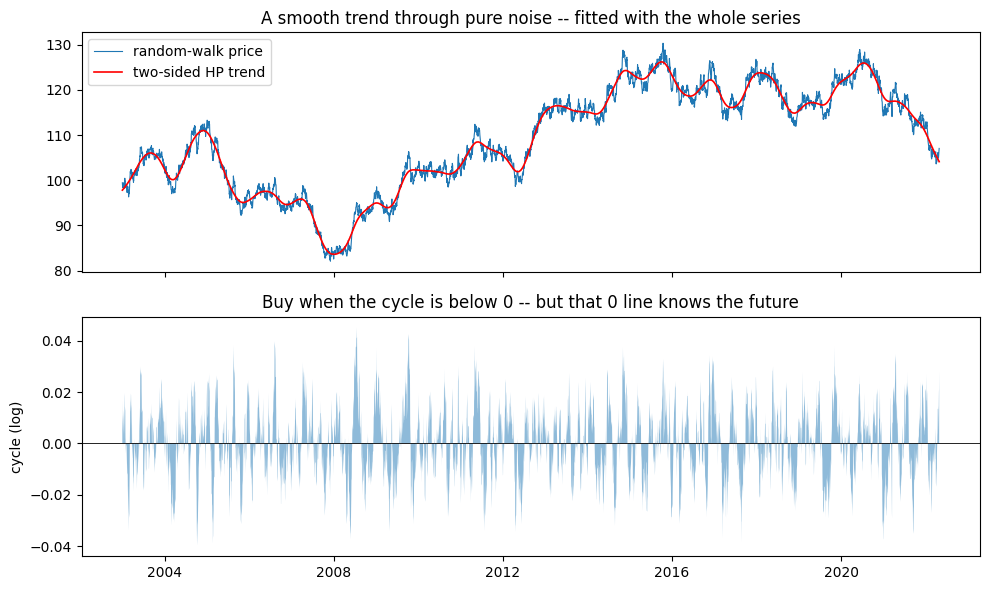

In [2]:
yl = np.log(close0); tau = hp.hp_trend_twosided(yl, LAM); c = yl - tau
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
a1.plot(close0.index, close0.values, lw=.8, label='random-walk price'); a1.plot(tau.index, np.exp(tau).values, 'r', lw=1.2, label='two-sided HP trend')
a1.legend(); a1.set_title('A smooth trend through pure noise -- fitted with the whole series')
a2.fill_between(c.index, c.values, 0, alpha=.5); a2.axhline(0, c='k', lw=.6); a2.set_ylabel('cycle (log)')
a2.set_title('Buy when the cycle is below 0 -- but that 0 line knows the future')
plt.tight_layout(); plt.show()

## 2 · So what? 💰

If it were real, it would be a money machine — a high-Sharpe, market-neutral edge on every asset, from a respectable off-the-shelf filter. That's exactly why this matters: the trap is *seductive and respectable*. Thousands of backtests — in papers, in blogs, in pitch decks — use a full-sample filter, a full-sample z-score, a full-sample normalisation, and quietly leak the future. Learn to spot this one and you'll spot them all.

## 3 · How we'd know 🔬

Three checks:

1. **Random-walk control.** Run it where there is *nothing* to find. Any edge is artefact.
2. **Go causal.** Recompute the trend from a trailing window (past only) and re-run.
3. **The smoking gun.** Correlate today's cycle with *future* returns — a two-sided filter that peeks will show a correlation it has no honest right to.

**Busted line:** the edge is huge two-sided, ~0 one-sided, and the two-sided cycle predicts the future it was built from.

## 4 · The teardown 🔧

### 4a · The same rule, peeking vs honest
Run the cycle-reversion book two ways on the **random walk**: two-sided (uses the future) and one-sided (causal, trailing window).

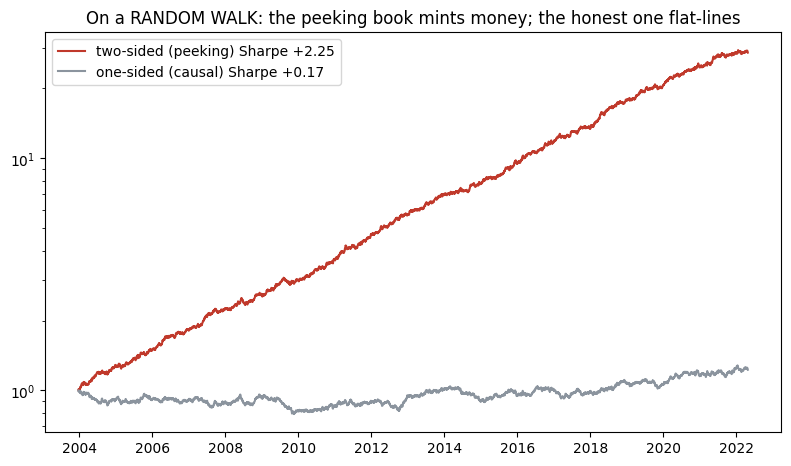

In [3]:
two = strategy.reversion_returns(close0, cost_bps=1.0, lam=LAM, causal=False)
one = strategy.reversion_returns(close0, cost_bps=1.0, lam=LAM, causal=True)
idx = one.index.intersection(two.index)
eq2 = (1+two.reindex(idx)).cumprod(); eq1 = (1+one.reindex(idx)).cumprod()
fig, ax = plt.subplots()
ax.plot(eq2.index, eq2.values, color='#c0392b', label=f"two-sided (peeking) Sharpe {strategy.summary(two.reindex(idx))['sharpe']:+.2f}")
ax.plot(eq1.index, eq1.values, color='#8b949e', label=f"one-sided (causal) Sharpe {strategy.summary(one.reindex(idx))['sharpe']:+.2f}")
ax.set_yscale('log'); ax.legend(); ax.set_title('On a RANDOM WALK: the peeking book mints money; the honest one flat-lines')
plt.show()

There is **nothing to trade** on a random walk — yet the two-sided book climbs relentlessly. Every cent of it is look-ahead.

### 4b · The smoking gun — the cycle 'predicts' the future
Correlate today's cycle with the return over the next few days. The two-sided cycle was *built* from those returns, so it 'predicts' them; the causal cycle can't, so it doesn't.

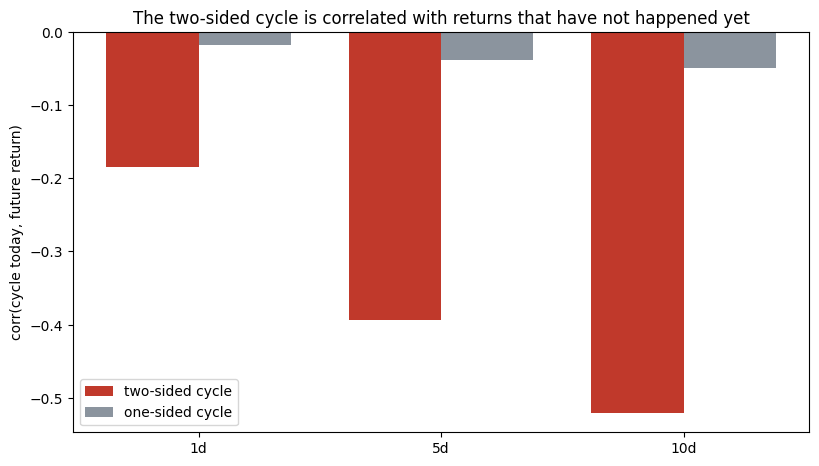

In [4]:
fl = decompose.future_leakage(close0, lam=LAM)
hs = list(fl.keys())
two_c = [fl[h]['two_sided_corr'] for h in hs]; one_c = [fl[h]['one_sided_corr'] for h in hs]
x = np.arange(len(hs)); w = .38
fig, ax = plt.subplots()
ax.bar(x-w/2, two_c, w, color='#c0392b', label='two-sided cycle'); ax.bar(x+w/2, one_c, w, color='#8b949e', label='one-sided cycle')
ax.axhline(0, c='k', lw=.6); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('corr(cycle today, future return)'); ax.legend()
ax.set_title('The two-sided cycle is correlated with returns that have not happened yet')
plt.show()

### 4c · The honest filter isn't broken — it just won't hallucinate
Run the causal version on a tape that *does* mean-revert. It finds a small, real edge — proof the one-sided filter works; it simply refuses to invent one from noise.

In [5]:
for label, c in [('random walk', close0), ('real mean-reversion', close)]:
    he = decompose.honest_edge(c, cost_bps=1.0, lam=LAM)
    print(f"{label:20s}: one-sided (honest) Sharpe {he['sharpe']:+.2f} (HAC t {he['t_stat']:+.1f})")

random walk         : one-sided (honest) Sharpe +0.17 (HAC t +0.8)


real mean-reversion : one-sided (honest) Sharpe +0.71 (HAC t +3.3)


### 4d · On the real market — same fabricated edge
On real ETFs (quoted from [`../docs/results.md`](../docs/results.md)): the two-sided book shows a Sharpe of **+1.93** on SPY at a *t* of **+12.6** — and the causal version, **+0.11** (*t* +0.7). The cycle's correlation with the next 5-day return is **-0.40** two-sided vs **-0.08** one-sided. The market behaves exactly like the random walk: the 'edge' is the filter peeking.

## 5 · The verdict 🧾

- **Fake on noise** — Sharpe ~2 two-sided on a random walk; ~0 one-sided.
- **Caught in the act** — the two-sided cycle correlates with the future it used.
- **Nothing survives** — the honest, causal book has no edge on the real tape.

> **Signal `NONE` · Tradability `MIRAGE` · Look-ahead bias `BUSTED`.** A respectable filter, used innocently, smuggles the future into the past.

## 6 · Could you trade it? 💸

**No — you can't even compute the signal in real time.** The two-sided HP trend for *today* needs *all future prices*; live, you'd have to use the causal filter, which earns nothing. There's no execution detail to optimise, no cost to haggle over — the strategy simply does not exist outside a full-sample backtest.

> Tradability **`MIRAGE`** in the purest sense: the paper edge has no live counterpart.

## 7 · Going further 🚪

- **It survives every check but causality** (beat 7 of the quants notebook + [`../docs/extension.md`](../docs/extension.md)): charge more cost, vary the smoothing — the fake edge laughs them off. The *only* test that kills it is recomputing the filter on past data.
- **The lesson generalises.** Any full-sample transform — a two-sided filter, a z-score by full-sample mean/vol, a regression fit on all the data — leaks the future. The universal fix: compute it causally; the universal test: does perturbing a *future* point move a *past* signal value?
- **A causal HP via Kalman.** The one-sided HP is the Kalman-filtered local-linear-trend; a proper state-space version would be smoother than our rolling-window endpoint — does any real edge appear then? (We bet not.)

PRs welcome — find a *causal* HP variant with a real edge, or add the next full-sample-leak to the desk's trap museum.